#[Baseline] Data Analysis Competition: NFL Draft Prediction

In this notebook, you will build a **baseline model** for the task of predicting whether a player will be selected in the NFL Draft (**Drafted**) based on sports performance test results and player information.

A baseline model is a simple initial model built for a given machine learning task. It serves as a starting point for further model development and performance improvements.

By running this notebook from top to bottom, you will generate a prediction file that can be submitted successfully.

##Table of Contents
1. Setup

2. Load the Data

3. Data Analysis & EDA

4. Preprocessing

5. Baseline Model

6. Hypothesis & Feature Engineering

7. Create the Submission File

8. Next Steps

## 1.Setup

In [143]:
# Import modules
import numpy as np  # Library for numerical computing and array operations
import pandas as pd  # Library for handling tabular data
import matplotlib.pyplot as plt  # Library for basic data visualization
import seaborn as sns  # Library for statistical data visualization
from sklearn.preprocessing import LabelEncoder  # Encoder for converting categorical variables to numeric labels
from sklearn.ensemble import RandomForestClassifier  # Random Forest classifier
from sklearn.model_selection import StratifiedKFold  # Class for stratified K-fold cross-validation
from sklearn.metrics import roc_auc_score  # Metric function for computing ROC AUC
from sklearn.linear_model import LogisticRegression # Logistic Regression classifier

In [149]:
from lightgbm import LGBMClassifier # LightGBM classifier

In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In this notebook, we assume the following directory structure in your Google Drive:
```
MyDrive/
└── GCI/
    └── competition/
        ├──README.ipynb
        ├── baseline.ipynb  # This notebook (baseline)
        └── input/
            ├── train.csv  # Training data
            ├── test.csv  # Test data (for prediction)
            └── sample_submission.csv  # Sample submission file

```

## 2.Load the data

### 2.1 Connect with Google Drive
To load the data, we first need to connect this Colab notebook with Google Drive.

In [68]:
# If you work with Google Colaboratory, please run this as well.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Next, we need to navigate to where the `competition` folder is located

**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Examples:
- You uploaded `competition` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/competition"
- You uploaded `competition` folder inside a folder named `00_GCIGlobal` under MyDrive
    - Change to "/<wbr>content/drive/MyDrive/00_GCIGlobal/competition"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

In [69]:
# Specify the directory where this notebook is located after %cd.
%cd "/content/drive/MyDrive/PYTHON/GCI World 2026/competition-20260605T143322Z-3-001/competition"

/content/drive/MyDrive/PYTHON/GCI World 2026/competition-20260605T143322Z-3-001/competition


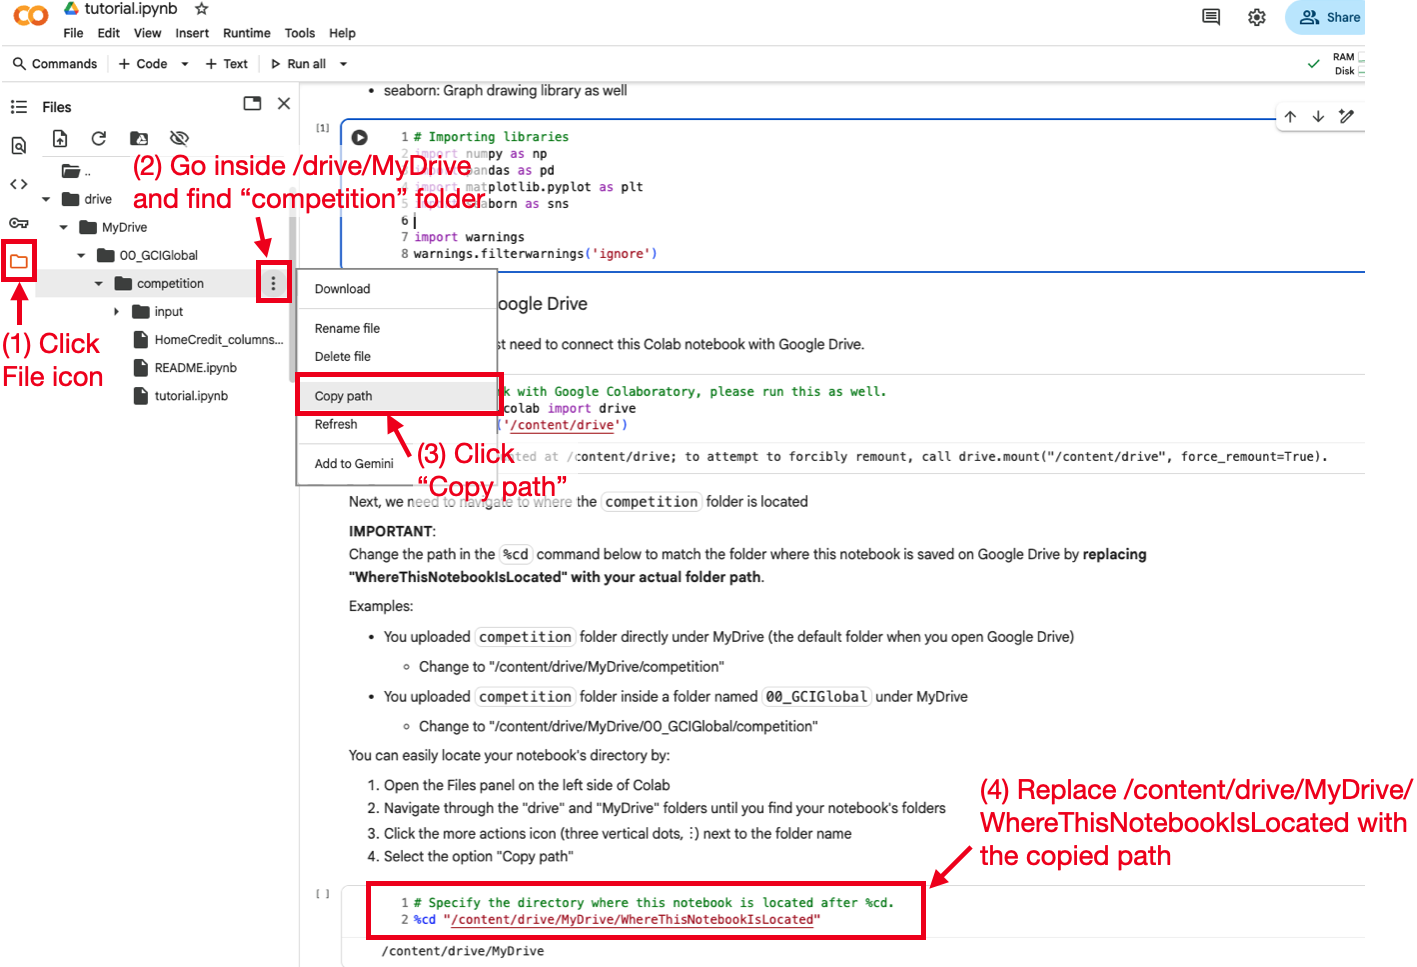

Run the cell below to check if the path is correctly set.

In [70]:
from pathlib import Path

PATH = Path.cwd() / "input"

train_file = PATH / "train.csv"
test_file = PATH / "test.csv"
sample_sub_file = PATH / "sample_submission.csv"

# Check if path exists
if train_file.exists() and test_file.exists() and sample_sub_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


### 2.2 Data Overview
Run the cell to load the dataset as `pd.DataFrame`.

**IMPORTANT:**<br>
**When you make modifications to preprocessing or model training, always make sure to run all cells from this cell.**

In [71]:
PATH = Path.cwd() / "input"

train = pd.read_csv(PATH / "train.csv")
test = pd.read_csv(PATH / "test.csv")
sample_sub = pd.read_csv(PATH / "sample_submission.csv")

print(f"train: {train.shape}, test: {test.shape}, sample_sub: {sample_sub.shape}")

train: (2781, 16), test: (696, 15), sample_sub: (696, 2)


First, let's check the shape of the dataset.

In [72]:
print('Train:', train.shape)
print('Test:', test.shape)

Train: (2781, 16)
Test: (696, 15)


We can see that the training data contains **2,781 rows** and **16 columns**, while the test data contains **696 rows** and **15 columns**.
The test data has one fewer column because it does not include the target variable to be predicted.

Next, let's take a look at the **first five rows** of the training data.

In [73]:
train.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,Drafted
0,0,2011,21.0,Lehigh,1.9050,140.160042,5.39,59.69,29.0,251.46,7.91,4.94,offense,offensive_lineman,OG,1.0
1,1,2011,24.0,Abilene Christian,1.8288,87.089735,4.31,101.60,16.0,332.74,NaN,NaN,offense,backs_receivers,WR,1.0
2,2,2018,21.0,Colorado St.,1.8542,92.986436,4.51,91.44,10.0,309.88,6.95,4.37,offense,backs_receivers,WR,1.0
3,3,2010,21.0,East Carolina,1.9304,148.778297,5.09,76.20,39.0,254.00,8.12,4.71,defense,defensive_lineman,DT,1.0
4,4,2016,21.0,California,1.8796,92.079251,4.64,78.74,NaN,281.94,7.13,4.20,offense,backs_receivers,WR,1.0


In [74]:
test.head()

,Id,Year,Age,School,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position
0,2781,2017,22.0,Pittsburgh,1.9558,136.077711,5.27,76.20,21.0,289.56,8.39,5.09,offense,offensive_lineman,OG
1,2782,2013,22.0,William & Mary,1.7780,83.460996,4.51,102.87,14.0,335.28,6.82,3.84,defense,defensive_back,CB
2,2783,2018,21.0,Alabama,1.8542,103.419060,4.52,101.60,14.0,327.66,NaN,4.34,offense,backs_receivers,RB
3,2784,2009,21.0,Georgia,1.8034,98.429544,4.50,90.17,25.0,292.10,6.84,4.27,offense,backs_receivers,RB
4,2785,2018,23.0,Alabama,1.8288,83.914588,4.36,80.01,13.0,302.26,6.93,4.40,defense,defensive_back,CB


You can view detailed information about a pandas DataFrame by using `.info()`.

In [75]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2781 entries, 0 to 2780
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                2781 non-null   int64  
 1   Year              2781 non-null   int64  
 2   Age               2346 non-null   float64
 3   School            2781 non-null   object 
 4   Height            2781 non-null   float64
 5   Weight            2781 non-null   float64
 6   Sprint_40yd       2636 non-null   float64
 7   Vertical_Jump     2227 non-null   float64
 8   Bench_Press_Reps  2060 non-null   float64
 9   Broad_Jump        2200 non-null   float64
 10  Agility_3cone     1811 non-null   float64
 11  Shuttle           1869 non-null   float64
 12  Player_Type       2781 non-null   object 
 13  Position_Type     2781 non-null   object 
 14  Position          2781 non-null   object 
 15  Drafted           2781 non-null   float64
dtypes: float64(10), int64(2), object(4)
memory

In [76]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                696 non-null    int64  
 1   Year              696 non-null    int64  
 2   Age               581 non-null    float64
 3   School            696 non-null    object 
 4   Height            696 non-null    float64
 5   Weight            696 non-null    float64
 6   Sprint_40yd       667 non-null    float64
 7   Vertical_Jump     553 non-null    float64
 8   Bench_Press_Reps  512 non-null    float64
 9   Broad_Jump        549 non-null    float64
 10  Agility_3cone     449 non-null    float64
 11  Shuttle           468 non-null    float64
 12  Player_Type       696 non-null    object 
 13  Position_Type     696 non-null    object 
 14  Position          696 non-null    object 
dtypes: float64(9), int64(2), object(4)
memory usage: 81.7+ KB


In [77]:
train.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Drafted
count,2781.000000,2781.000000,2346.000000,2781.000000,2781.000000,2636.000000,2227.000000,2060.000000,2200.000000,1811.000000,1869.000000,2781.000000
mean,1390.000000,2013.838907,21.997016,1.873590,109.502026,4.764818,83.506349,20.236408,291.985700,7.230447,4.399422,0.648328
std,802.949874,3.083247,0.964836,0.067178,20.307239,0.299343,10.710691,6.410662,23.924666,0.410686,0.263851,0.477578
min,0.000000,2009.000000,18.000000,1.651000,67.585263,4.220000,44.450000,2.000000,198.120000,6.280000,3.820000,0.000000
25%,695.000000,2011.000000,21.000000,1.828800,92.986436,4.530000,76.200000,16.000000,276.860000,6.930000,4.200000,0.000000
50%,1390.000000,2014.000000,22.000000,1.879600,104.779837,4.680000,83.820000,20.000000,294.640000,7.130000,4.350000,1.000000
75%,2085.000000,2017.000000,23.000000,1.930400,124.284309,4.950000,91.440000,24.000000,307.340000,7.490000,4.560000,1.000000
max,2780.000000,2019.000000,28.000000,2.082800,162.386068,6.000000,114.300000,45.000000,373.380000,9.040000,5.560000,1.000000


In [78]:
test.describe()

,Id,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle
count,696.000000,696.000000,581.000000,696.000000,696.000000,667.000000,553.000000,512.000000,549.000000,449.000000,468.000000
mean,3128.500000,2013.762931,21.927711,1.875476,110.722810,4.785922,82.933526,20.259766,290.203097,7.265523,4.421496
std,201.062179,3.046376,0.986953,0.068770,21.161295,0.309420,10.544504,6.842719,24.074513,0.407634,0.270203
min,2781.000000,2009.000000,19.000000,1.676400,76.657111,4.280000,52.070000,6.000000,210.820000,6.500000,3.810000
25%,2954.750000,2011.000000,21.000000,1.828800,92.986436,4.540000,74.930000,15.000000,276.860000,6.980000,4.220000
50%,3128.500000,2014.000000,22.000000,1.879600,104.779837,4.700000,83.820000,20.000000,294.640000,7.180000,4.380000
75%,3302.250000,2016.000000,23.000000,1.930400,131.995380,5.005000,90.170000,25.000000,307.340000,7.500000,4.592500
max,3476.000000,2019.000000,27.000000,2.032000,167.375585,5.760000,111.760000,49.000000,345.440000,8.720000,5.380000


In [79]:
unique_values={col:train[col].unique() for col in train.columns }
for col, values in unique_values.items():
  print(f"Columna: {col}")
  print(f"numero de valores unicos: {len(values)}")
  print(f"valores unicos: {values[:10]}")
  print("--"*50)

Columna: Id
numero de valores unicos: 2781
valores unicos: [0 1 2 3 4 5 6 7 8 9]
----------------------------------------------------------------------------------------------------
Columna: Year
numero de valores unicos: 11
valores unicos: [2011 2018 2010 2016 2015 2012 2019 2014 2017 2013]
----------------------------------------------------------------------------------------------------
Columna: Age
numero de valores unicos: 10
valores unicos: [21. 24. 23. 22. 20. nan 26. 25. 18. 28.]
----------------------------------------------------------------------------------------------------
Columna: School
numero de valores unicos: 236
valores unicos: ['Lehigh' 'Abilene Christian' 'Colorado St.' 'East Carolina' 'California'
 'Fresno St.' 'Utah St.' 'Missouri' 'Pittsburgh' 'Nevada']
----------------------------------------------------------------------------------------------------
Columna: Height
numero de valores unicos: 18
valores unicos: [1.905  1.8288 1.8542 1.9304 1.8796 1.7526 1.955

In [80]:
train.duplicated().sum()

np.int64(0)

In [81]:
test.duplicated().sum()

np.int64(0)

### [Next Steps]

This section only loaded the data. A few easy starting points to dig deeper before EDA:

- Run `train.describe()` and `test.describe()` to see summary statistics for the numerical columns.
- Check for duplicate rows with `train.duplicated().sum()`.
- Compare basic statistics (mean, std, min, max) between **train** and **test** to check whether the two splits look similar.

## 3.Data Analysis & EDA

**EDA (Exploratory Data Analysis)** is an essential step for understanding the structure and characteristics of your data before building a model.

At this stage, you explore trends and patterns in the dataset, as well as **outliers**, **missing values**, and **imbalanced distributions**. For example, some variables may contain extreme values, or the data may be heavily skewed toward specific categories. Identifying these characteristics helps you find potential issues that could hurt performance and uncover features that may be useful for prediction.

By performing EDA, you can detect and address problems early—such as “training fails due to missing values” or “the model becomes unstable because of outliers.” This reduces rework later and enables more efficient preprocessing and feature engineering.

Insights from EDA also inform later decisions, including model selection and hyperparameter tuning. In machine learning competitions, EDA is often a key process for improving final scores.

### 3.1 Checking Missing Values

First, let's check for missing values. This is an essential step in machine-learning-based data analysis, because most machine learning models cannot train on or make predictions from data that contains missing values, and will raise an error.

In [82]:
train.isnull().sum()

,0
Id,0
Year,0
Age,435
School,0
Height,0
Weight,0
Sprint_40yd,145
Vertical_Jump,554
Bench_Press_Reps,721
Broad_Jump,581


In [83]:
test.isnull().sum()

,0
Id,0
Year,0
Age,115
School,0
Height,0
Weight,0
Sprint_40yd,29
Vertical_Jump,143
Bench_Press_Reps,184
Broad_Jump,147


We found missing values in the following columns: **Age**,**Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. We will handle these later.

### 3.2 Visualization and Analysis

Next, let's look at how many players were drafted.

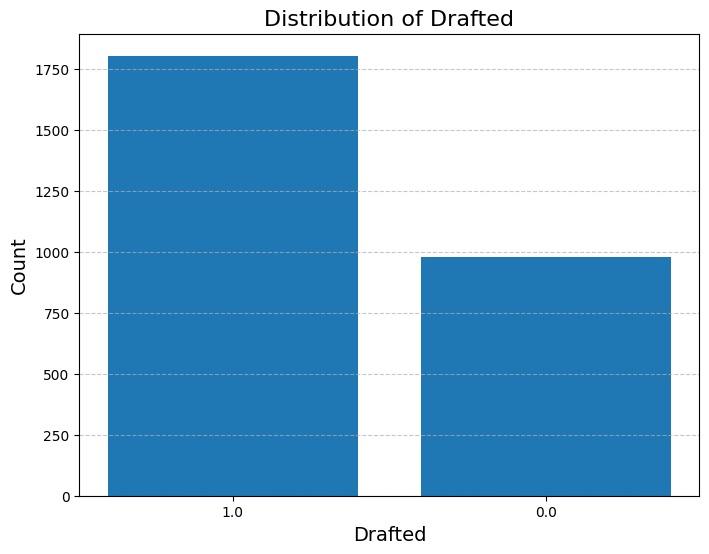

In [84]:
drafted_counts = train['Drafted'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(drafted_counts.index.astype(str), drafted_counts.values)
plt.title('Distribution of Drafted', fontsize=16)
plt.xlabel('Drafted', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

We can see that there are more players with **Drafted = 1** than those with **Drafted = 0**. Let's check the propotions.

In [85]:
drafted_percentage = train['Drafted'].value_counts(normalize=True) * 100

print(f"Percentage of 0: {drafted_percentage.get(0, 0):.2f}%")
print(f"Percentage of 1: {drafted_percentage.get(1, 0):.2f}%")

Percentage of 0: 35.17%
Percentage of 1: 64.83%


In [86]:
print(len(numeric_cols))

2781


We found that about **35%** of the players were **not drafted**, while about **65%** were **drafted**.

Next, we will continue EDA for the other features. First, let's visualize the numerical variables excluding the **"Id"** and **"Drafted"** columns.

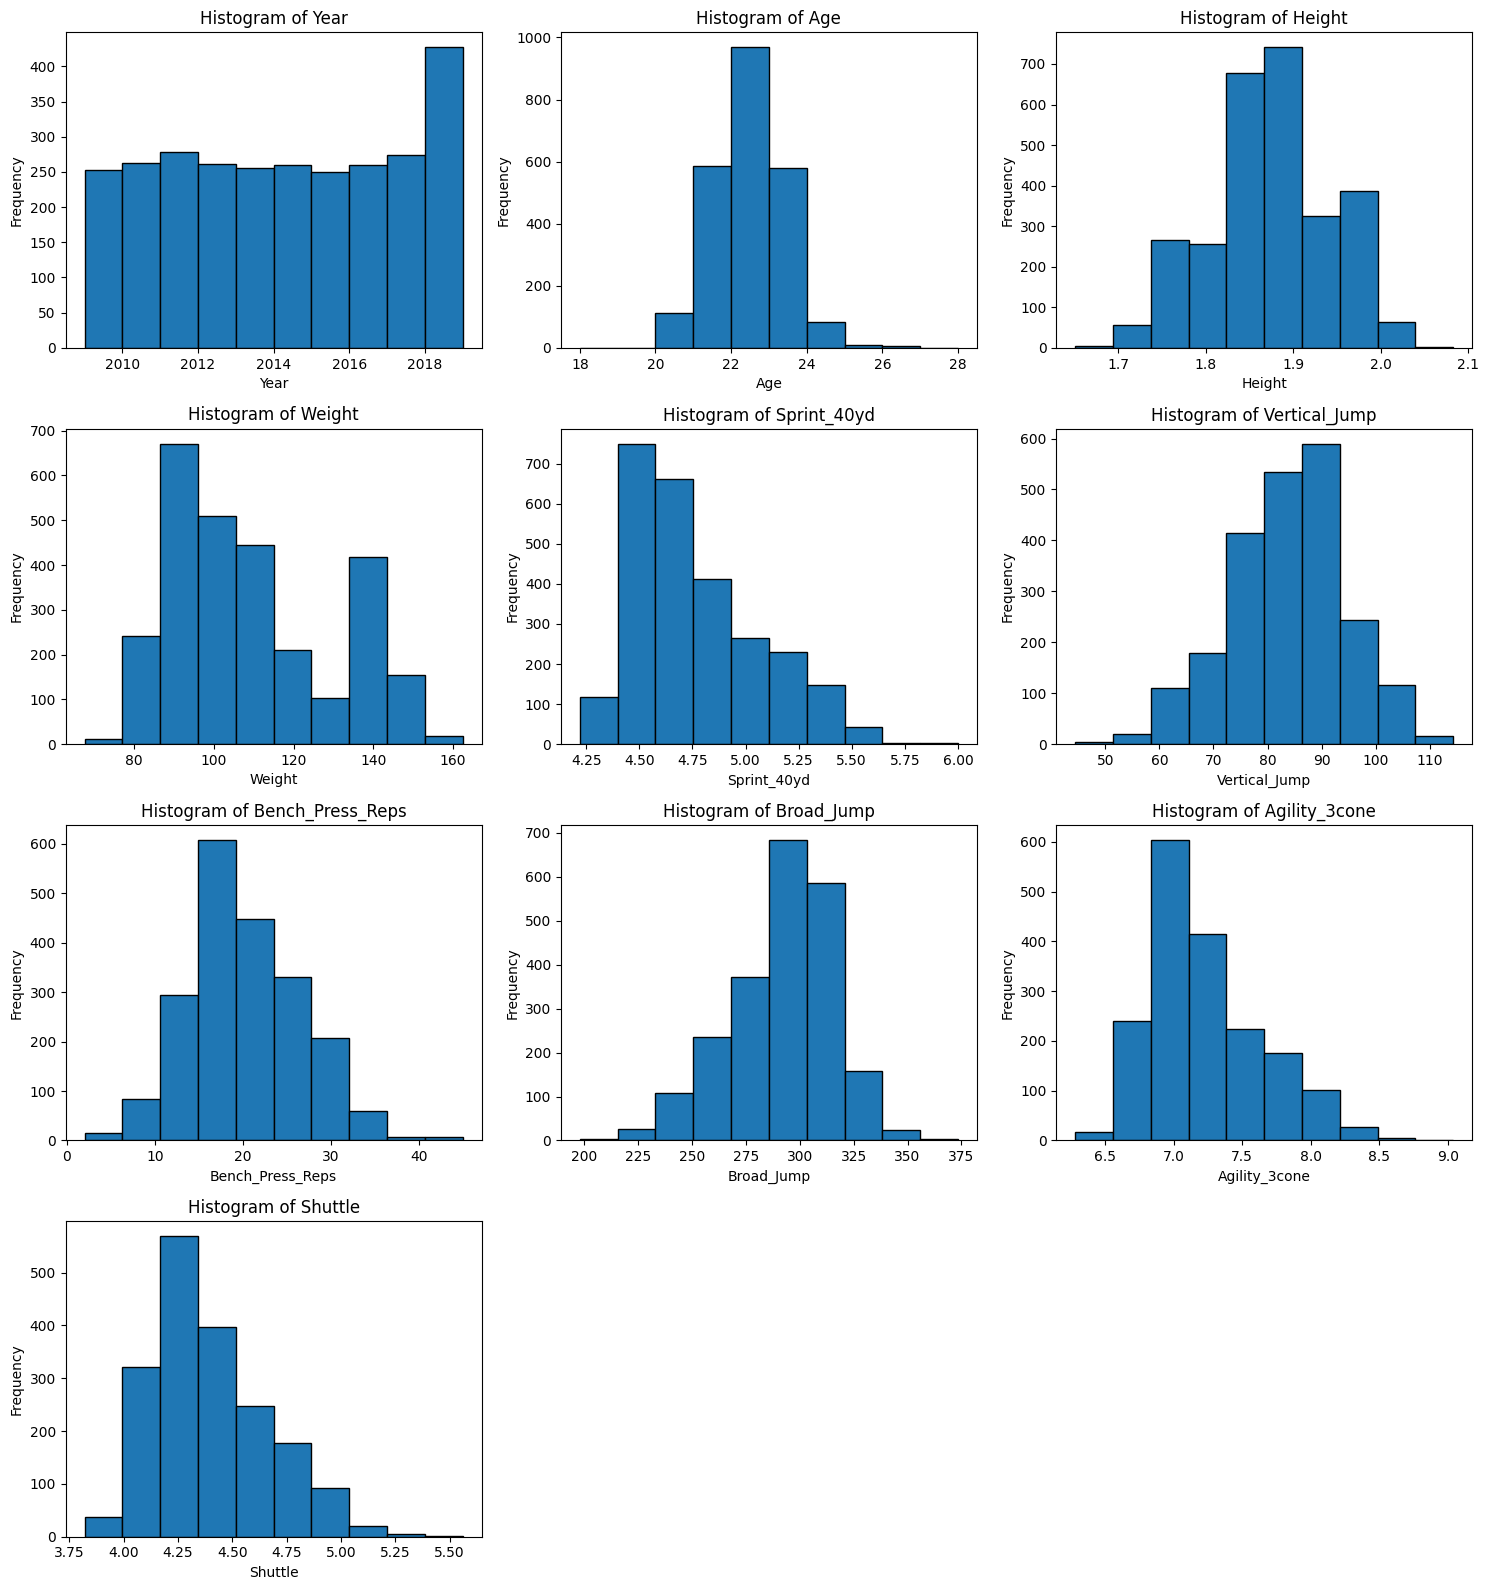

In [87]:
# Extraxt numeric columns (excluding the 'Id' and 'Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Id', 'Drafted'])

# Plot
num_cols = len(numeric_cols)
cols = 3
rows = (num_cols + cols - 1) // cols

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(rows, cols, i)
    plt.hist(train[col].dropna(), bins=10, edgecolor='black')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's examine the correlation matrix of the numerical features using a heatmap.

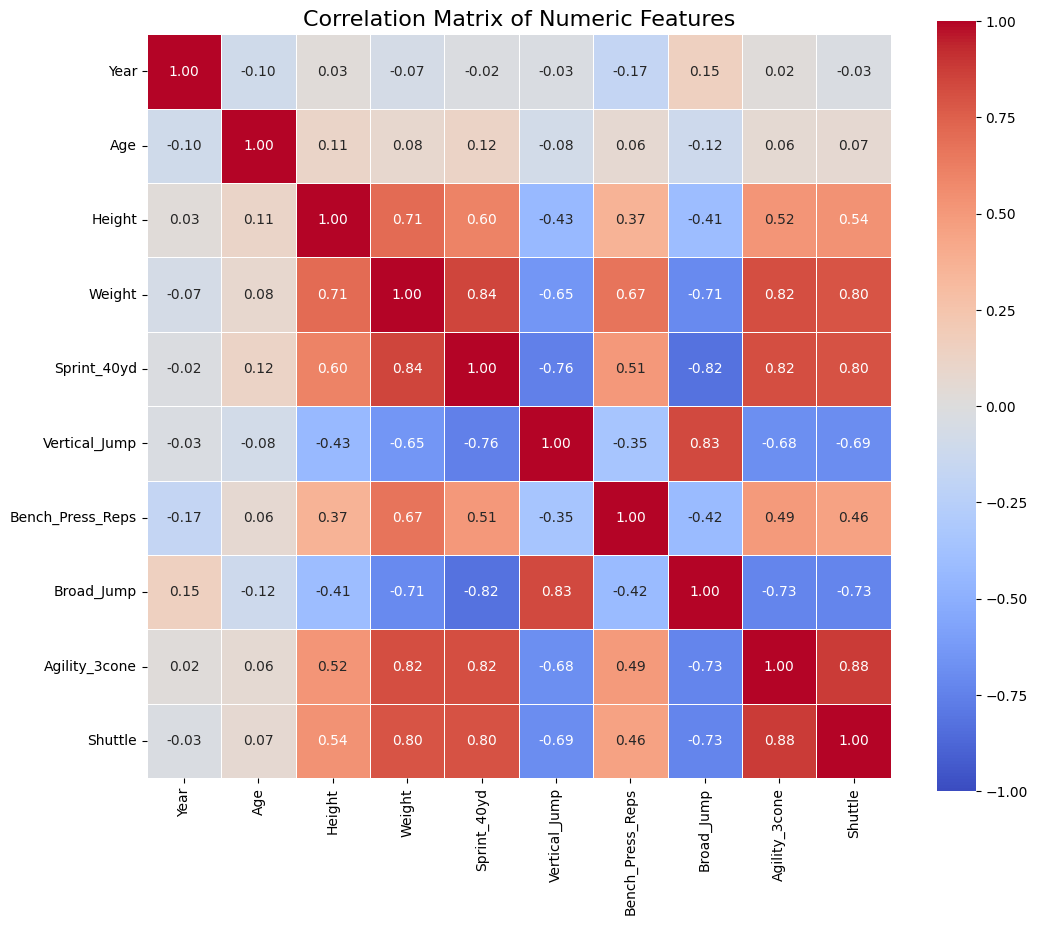

In [88]:
# Extract numeric columns (excluding the 'Id' and ''Drafted' columns)
numeric_cols = train.select_dtypes(include=['number']).drop(['Id', 'Drafted'], axis=1)

# Compute the correlation matrix
corr_matrix = numeric_cols.corr()

# Plot a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5
)

plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

The correlation coefficient between **Agility_3cone** and **Shuttle** is **0.88**, indicating a strong positive relationship. These tests may rely on similar muscle groups and movement patterns.

On the other hand, the correlation coefficient between **Sprint_40yd** and **Broad_Jump** is **-0.82**, showing a strong negative relationship. Since both events mainly depend on lower-body power, we might normally expect their scores to move together (i.e., a positive correlation), but here we observe the opposite. To investigate this further, let’s visualize **Sprint_40yd**.

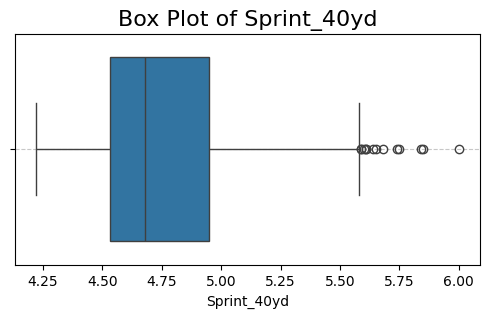

In [89]:
# Plot a boxplot
plt.figure(figsize=(6, 3))
sns.boxplot(x=train['Sprint_40yd'])

plt.title('Box Plot of Sprint_40yd', fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

From the plot, we can see that values in **Sprint_40yd** are roughly distributed between **4.25** and **6.00**. This suggests the column likely represents the **actual sprint time**, not a “score.” A median of around **4.7 seconds** is reasonable for a 40-yard (about 36-meter) dash.

In other words, **smaller values** in **Sprint_40yd** mean faster times, so **lower is better**—the opposite direction from metrics where **higher values indicate better performance**. This explains why we observed a negative correlation with **Broad_Jump**.

By visualizing the data, we were able to answer the question: **“Why is there a negative correlation?”**

Next, let's visualize the categorical features.

In [90]:
# Extract categorical features
categorical_cols = train.select_dtypes(include=['object', 'category']).columns

# Get the number of unique categories in each column
levels_count = {col: train[col].nunique() for col in categorical_cols}

for col, count in levels_count.items():
    print(f"{col}: {count} levels")


School: 236 levels
Player_Type: 3 levels
Position_Type: 7 levels
Position: 20 levels


**'School'** has **236** unique values, which is too many to visualize clearly, so we will exclude it from the plots here.

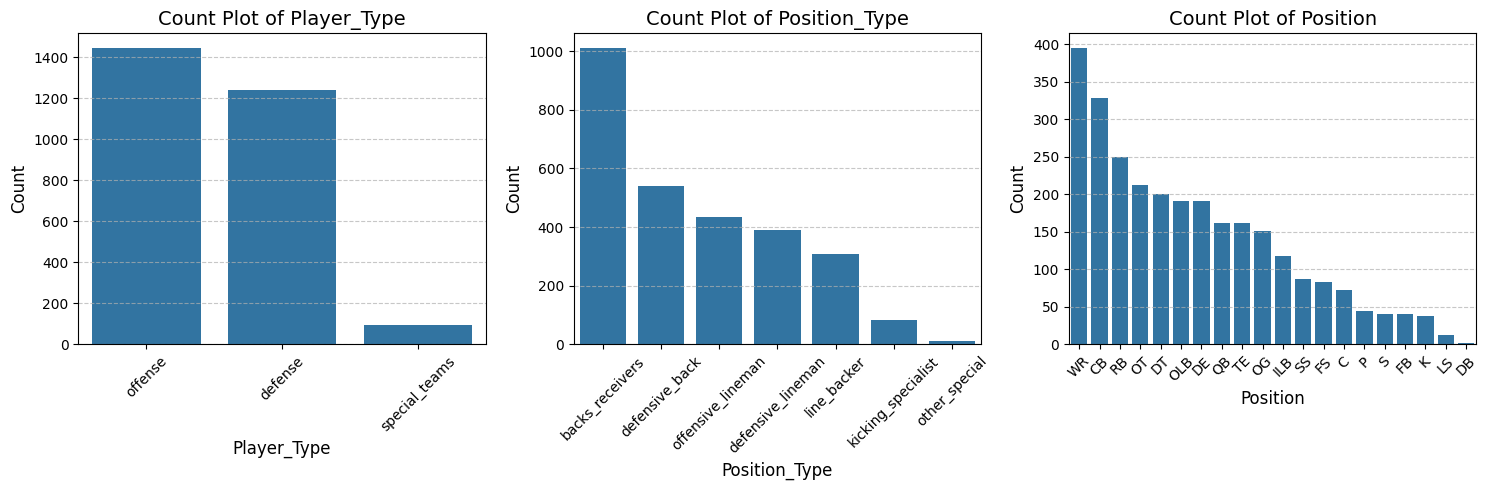

In [91]:
# Extract categorical features (object or category) and exclude the 'School' columns
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Count plots for each categorical features
for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=train, order=train[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

We can see that the number of samples varies widely across categories. For example, in the **Player_Type** column, the **special_teams** category has very few samples.

Next, let's visualize the **mean value of "Drafted"** for each category level. This helps us understand, visually, which positions are more likely to be drafted.

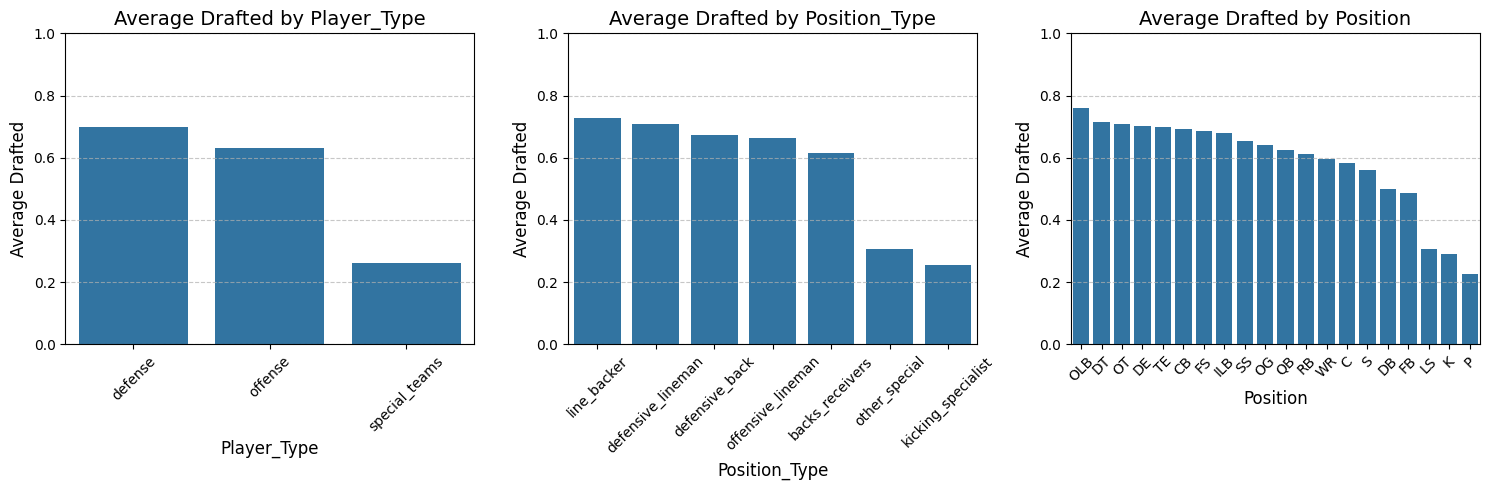

In [92]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols = train.select_dtypes(include=['object', 'category']).columns
categorical_cols = categorical_cols.drop('School')

# Prepare for plotting
num_cols = len(categorical_cols)
rows = 1
cols = num_cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5))

if cols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# Plot the mean value of 'Drafted' for each categorical feature as bar charts
for i, col in enumerate(categorical_cols):
    mean_values = train.groupby(col)['Drafted'].mean().sort_values(ascending=False)
    sns.barplot(x=mean_values.index, y=mean_values.values, ax=axes[i])
    axes[i].set_title(f'Average Drafted by {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Average Drafted', fontsize=12)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


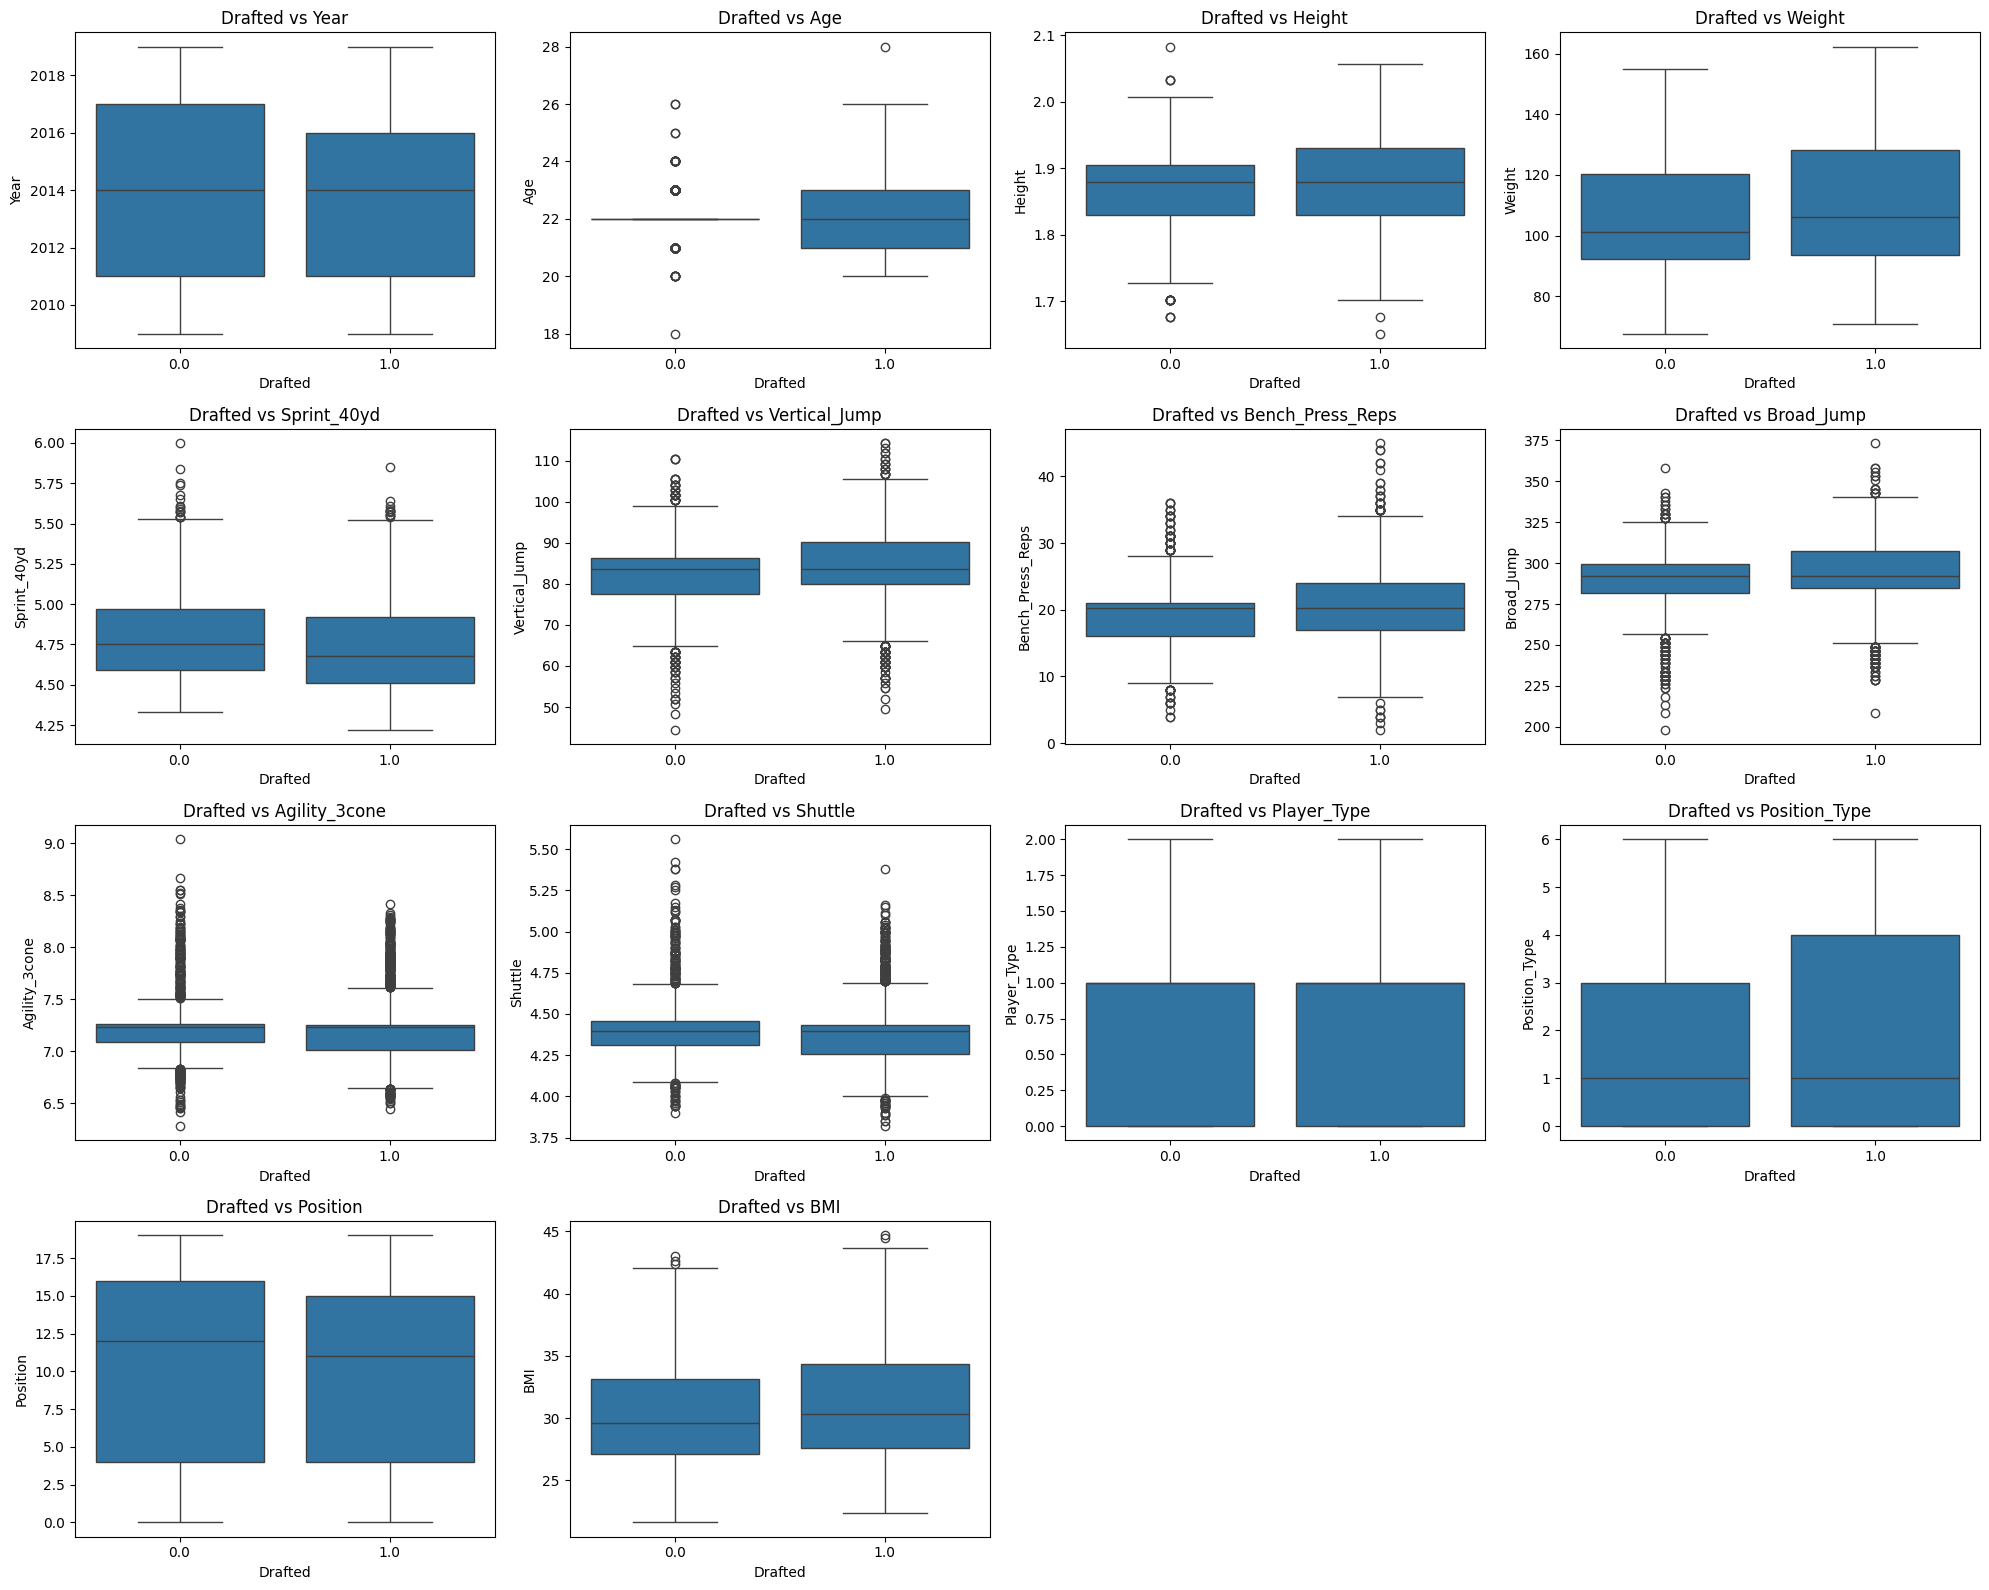

In [108]:
numeric_cols = train.select_dtypes(include=['number']).columns
numeric_cols = numeric_cols.drop(['Drafted']) # 'Id' is already dropped from the DataFrame

# Calculate number of rows needed for 4 columns
num_numerical_features = len(numeric_cols)
cols = 4
rows = (num_numerical_features + cols - 1) // cols

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Plot boxplots for each numerical feature against 'Drafted'
for i, col in enumerate(numeric_cols):
    sns.boxplot(x='Drafted', y=col, data=train, ax=axes[i])
    axes[i].set_title(f'Drafted vs {col}')
    axes[i].set_xlabel('Drafted')
    axes[i].set_ylabel(col)

# Hide any unused subplots
for i in range(num_numerical_features, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

We can see that players with **Player_Type = "special_teams"** have a much lower draft rate than other players.
Similarly, players with **Position_Type = "other_special"** or **"kicking_specialist"**, and those with **Position = "LS"**, **"K"**, or **"P"**, also have relatively low draft rates.

### [Next Steps]

EDA is open-ended; here are some directions you can take next:

- Examine the relationship between each numerical feature and the target with grouped boxplots (`sns.boxplot(x='Drafted', y=col, ...)`).
- Cross-tabulate categorical features against **Drafted** to see which categories have a high or low draft rate.
- Investigate the **School** column more carefully — for example, group schools by conference or region and check the draft rate per group.
- Look for outliers in other numerical columns (e.g. **Bench_Press_Reps**, **Vertical_Jump**) and decide how to handle them.

### Cross-Tabulation of Categorical Features vs. Drafted Rate

In [111]:
# Extract categorical features (object or category) and exclude the 'School' column
categorical_cols_for_crosstab = original_train_df.select_dtypes(include=['object', 'category']).columns
categorical_cols_for_crosstab = categorical_cols_for_crosstab.drop('School', errors='ignore') # 'errors=ignore' to prevent error if 'School' is already dropped

print("Mean 'Drafted' Rate for Each Category:")
for col in categorical_cols_for_crosstab:
    print(f"\n--- {col} ---")
    # Create a cross-tabulation and calculate the mean of 'Drafted' for each category
    crosstab_df = pd.crosstab(original_train_df[col], original_train_df['Drafted'], normalize='index')
    # Display the percentage drafted (where 'Drafted' == 1)
    if 1.0 in crosstab_df.columns:
        print(crosstab_df[1.0].sort_values(ascending=False))
    else:
        print("No drafted players in this category.")

Mean 'Drafted' Rate for Each Category:

--- Player_Type ---
Player_Type
defense          0.698630
offense          0.630450
special_teams    0.263158
Name: 1.0, dtype: float64

--- Position_Type ---
Position_Type
line_backer           0.728155
defensive_lineman     0.708440
defensive_back        0.674677
offensive_lineman     0.664368
backs_receivers       0.615842
other_special         0.307692
kicking_specialist    0.256098
Name: 1.0, dtype: float64

--- Position ---
Position
OLB    0.759162
DT     0.715000
OT     0.707547
DE     0.701571
TE     0.697531
CB     0.692073
FS     0.686747
ILB    0.677966
SS     0.655172
OG     0.642384
QB     0.623457
RB     0.612000
WR     0.594937
C      0.583333
S      0.560976
DB     0.500000
FB     0.487805
LS     0.307692
K      0.289474
P      0.227273
Name: 1.0, dtype: float64


### Analyzing 'School' by Draft Rate

Top 10 Schools by Draft Rate:
School
Abilene Christian    1.0
Ala-Birmingham       1.0
Ashland              1.0
Ark-Pine Bluff       1.0
Concordia (MN)       1.0
Cal Poly             1.0
Citadel              1.0
Charlotte            1.0
Chadron St.          1.0
East. Illinois       1.0
Name: Drafted, dtype: float64


/tmp/ipykernel_18281/2104990614.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=school_draft_rates.head(10).index, y=school_draft_rates.head(10).values, palette='viridis')


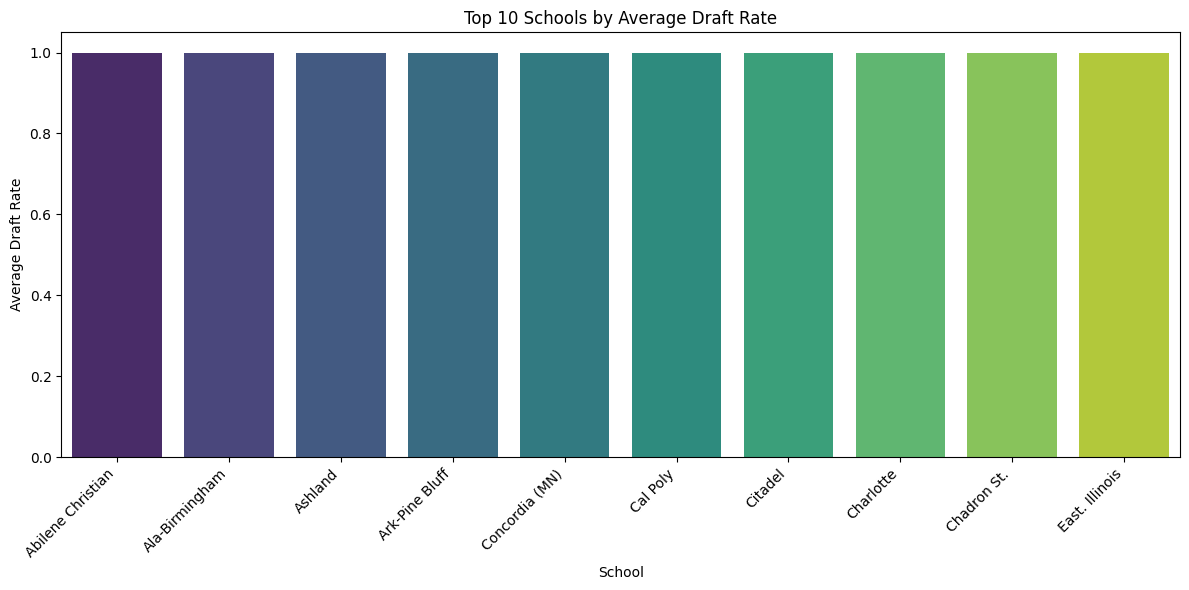

In [110]:
# Temporarily load the original train data to include the 'School' column for this analysis
# Note: This train_df variable is local to this cell and does not affect the global 'train' DataFrame
# which has 'School' already dropped for modeling purposes.
original_train_df = pd.read_csv(PATH / "train.csv")

# Calculate the mean 'Drafted' rate for each school
school_draft_rates = original_train_df.groupby('School')['Drafted'].mean().sort_values(ascending=False)

# Display the top 10 schools by draft rate
print("Top 10 Schools by Draft Rate:")
print(school_draft_rates.head(10))

# Optional: Visualize the top 10 schools
plt.figure(figsize=(12, 6))
sns.barplot(x=school_draft_rates.head(10).index, y=school_draft_rates.head(10).values, palette='viridis')
plt.title('Top 10 Schools by Average Draft Rate')
plt.xlabel('School')
plt.ylabel('Average Draft Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

This shows the schools with the highest average draft rates. To analyze by conference or region, you would need to find external data that maps schools to their respective conferences or regions and then merge that data with our current dataset.

## 4.Preprocessing

Here, we will conduct the preprocessing and create new features based on what we have learned in the preceding visualization and analysis. We will perform **missing value imputation** and **encoding**.

### 4.1 Dropping Columns

In this notebook, we will exclude categorical features with a relatively large number of unique levels. Specifically, we will drop the **School** column (**236** unique values). *(Note: School may still influence Drafted; if you want to explore further, try including it as a feature.)* We will also drop the **Id** column, since it is expected to be unrelated to whether a player is drafted.

In [93]:
# Drop unused columns
train = train.drop(columns=["Id", "School"])
test = test.drop(columns=["Id","School"])

### 4.2 Dealing Missing Values

There are missing values in **Age**, **Sprint_40yd**, **Vertical_Jump**, **Bench_Press_Reps**, **Broad_Jump**, **Agility_3cone**, and **Shuttle**. In this notebook, we will impute these missing values using the mean of each column.

In [94]:
# Columns to impute with the mean
cols_to_fill = ['Age', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps',
                'Broad_Jump', 'Agility_3cone', 'Shuttle']

# Impute both train and test using the means computed from the training data
for col in cols_to_fill:
    mean_value = train[col].mean()
    train[col] = train[col].fillna(mean_value)
    test[col] = test[col].fillna(mean_value)

Let's check whether there are any missing values.

In [113]:
train.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


In [114]:
test.isnull().sum()

,0
Year,0
Age,0
Height,0
Weight,0
Sprint_40yd,0
Vertical_Jump,0
Bench_Press_Reps,0
Broad_Jump,0
Agility_3cone,0
Shuttle,0


Now, the missing values in both **train** and **test** have been handled.

### 4.3 Dealing Categorical Data

Next, let's convert the categorical features into numerical values so they can be used as model imputs. Most machine learning models can only accept numerical data.

Here, we will use a technique called **label encoding**.

In [117]:
# Label-encode the categorical features
label_encoders = {}
for c in ["Player_Type", "Position_Type", "Position"]:
    label_encoders[c] = LabelEncoder()
    train[c] = label_encoders[c].fit_transform(train[c].astype(str))
    test[c] = label_encoders[c].transform(test[c].astype(str))

In [129]:
# one hot-Label encoding the categorical features
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Initialize the dictionaries for one-hot encoded features
train_one_hot_label_encoders = {}
test_one_hot_label_encoders = {}

# Note: 'label_encoders' is not used in this specific one-hot encoding process
# as pd.get_dummies directly creates dummy variables.
label_encoders = {}

for c in ["Player_Type", "Position_Type", "Position"]:
    train_one_hot_label_encoders[c] = pd.get_dummies(train[c], prefix=c)
    test_one_hot_label_encoders[c] = pd.get_dummies(test[c], prefix=c)

In [136]:
print("One-hot encoded features for training data:")
for feature_name, df_one_hot in train_one_hot_label_encoders.items():
    # Convert boolean columns to integers (0s and 1s)
    df_one_hot = df_one_hot.astype(int)
    print(f"\nFeature: {feature_name}")
    display(df_one_hot.head())

One-hot encoded features for training data:

Feature: Player_Type


,Player_Type_0,Player_Type_1,Player_Type_2
0,0,1,0
1,0,1,0
2,0,1,0
3,1,0,0
4,0,1,0



Feature: Position_Type


,Position_Type_0,Position_Type_1,Position_Type_2,Position_Type_3,Position_Type_4,Position_Type_5,Position_Type_6
0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,0
2,1,0,0,0,0,0,0
3,0,0,1,0,0,0,0
4,1,0,0,0,0,0,0



Feature: Position


,Position_0,Position_1,Position_2,Position_3,Position_4,Position_5,Position_6,Position_7,Position_8,Position_9,Position_10,Position_11,Position_12,Position_13,Position_14,Position_15,Position_16,Position_17,Position_18,Position_19
0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [137]:
print("One-hot encoded features for test data:")
for feature_name, df_one_hot in test_one_hot_label_encoders.items():
    # Convert boolean columns to integers (0s and 1s)
    df_one_hot = df_one_hot.astype(int)
    print(f"\nFeature: {feature_name}")
    display(df_one_hot.head())

One-hot encoded features for test data:

Feature: Player_Type


,Player_Type_0,Player_Type_1,Player_Type_2
0,0,1,0
1,1,0,0
2,0,1,0
3,0,1,0
4,1,0,0



Feature: Position_Type


,Position_Type_0,Position_Type_1,Position_Type_2,Position_Type_3,Position_Type_4,Position_Type_5
0,0,0,0,0,0,1
1,0,1,0,0,0,0
2,1,0,0,0,0,0
3,1,0,0,0,0,0
4,0,1,0,0,0,0



Feature: Position


,Position_0,Position_1,Position_2,Position_4,Position_5,Position_6,Position_7,Position_8,Position_9,Position_10,Position_11,Position_12,Position_13,Position_15,Position_16,Position_17,Position_18,Position_19
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### [Next Steps]

The preprocessing here is intentionally minimal. You can likely improve the score by changing how features are prepared:

- **Imputation**: try the median, a group-wise mean (e.g. mean by **Position**), or a model-based imputer such as `KNNImputer`.
- **Encoding**: try **One-Hot Encoding**, **Target (Mean) Encoding**, or **Frequency Encoding** instead of label encoding.
- **School**: rather than dropping it, try encoding it (e.g. target encoding or frequency encoding).
- Add a **missing-value indicator** (a 0/1 column that records whether the original value was missing).

## 5.Baseline Model

Now that the data has been prepared, we will use it as input to build a **baseline model**. A baseline model is a simple initial machine learning model that serves as a starting point.

In this notebook, we will use a **Random Forest** model, which is a tree-based method that makes predictions by combining many **decision trees**.

A decision tree is an intuitive model that repeatedly splits the data using simple “yes/no” questions. For example: “Is the player taller than 170 cm?” or “Is the player a kicker?” By following these conditions step by step, the model arrives at a final prediction.

However, using a single decision tree often leads to a model that fits the training data too closely and does not generalize well to new data—this is called **overfitting**. Random Forest addresses this by training dozens (or even hundreds) of decision trees, each on slightly different subsets of the data and features. It then combines their predictions—typically by averaging—resulting in a more stable and robust model.

To evaluate the model's performance, we will use **cross-validation**. This method splits the dataset into several groups (folds) and repeats training and evaluation multiple times.

In this notebook, we use **5-fold cross-validation**: the data is split into five folds, and each time we use one fold for validation and the remaining four folds for training. We repeat this process five times and take the average score as an estimate of model performance. Cross-validation is ueful because it provides a more reliable evaluation than a single train/validation split.

In [147]:
# Split into features and target
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and score
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.7861
Fold 2
  AUC: 0.8382
Fold 3
  AUC: 0.8359
Fold 4
  AUC: 0.775
Fold 5
  AUC: 0.8289

Average Validation AUC: 0.8128


This model achieved an AUC score of **0.8115**.

In [164]:
# Split into features and target
X_lr = train.drop(columns=["Drafted"])
y_lr = train["Drafted"]

# Set up the Logistic Regression model and cross-validation
model_lr = LogisticRegression(
    solver='liblinear', # 'liblinear' is a good choice for smaller datasets and handles L1/L2 penalties
    random_state=2025
)
skf_lr = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores_lr = []

print("Evaluating Logistic Regression Model:")
# Train and evaluate using Stratified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf_lr.split(X_lr, y_lr)):
    print(f"Fold {fold + 1}")

    X_train_lr, X_valid_lr = X_lr.iloc[train_idx], X_lr.iloc[valid_idx]
    y_train_lr, y_valid_lr = y_lr.iloc[train_idx], y_lr.iloc[valid_idx]

    # Train the model
    model_lr.fit(X_train_lr, y_train_lr)

    # Predict and score
    y_valid_pred_proba_lr = model_lr.predict_proba(X_valid_lr)[:, 1]
    auc_lr = roc_auc_score(y_valid_lr, y_valid_pred_proba_lr)
    auc_scores_lr.append(auc_lr)
    print(f"  AUC: {round(auc_lr, 4)}")

# Print mean AUC
mean_auc_lr = np.mean(auc_scores_lr)
print("\nAverage Validation AUC (Logistic Regression):", round(mean_auc_lr, 4))

Evaluating Logistic Regression Model:
Fold 1
  AUC: 0.6619
Fold 2
  AUC: 0.747
Fold 3
  AUC: 0.7453
Fold 4
  AUC: 0.6818
Fold 5
  AUC: 0.6595

Average Validation AUC (Logistic Regression): 0.6991


In [150]:
# Split into features and target
X_lgbm = train.drop(columns=["Drafted"])
y_lgbm = train["Drafted"]

# Set up the LightGBM model and cross-validation
model_lgbm = LGBMClassifier(
    random_state=2025,
    objective='binary', # For binary classification
    metric='auc' # Evaluate using AUC
)
skf_lgbm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores_lgbm = []

print("Evaluating LightGBM Model:")
# Train and evaluate using Stratified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf_lgbm.split(X_lgbm, y_lgbm)):
    print(f"Fold {fold + 1}")

    X_train_lgbm, X_valid_lgbm = X_lgbm.iloc[train_idx], X_lgbm.iloc[valid_idx]
    y_train_lgbm, y_valid_lgbm = y_lgbm.iloc[train_idx], y_lgbm.iloc[valid_idx]

    # Train the model
    model_lgbm.fit(X_train_lgbm, y_train_lgbm)

    # Predict and score
    y_valid_pred_proba_lgbm = model_lgbm.predict_proba(X_valid_lgbm)[:, 1]
    auc_lgbm = roc_auc_score(y_valid_lgbm, y_valid_pred_proba_lgbm)
    auc_scores_lgbm.append(auc_lgbm)
    print(f"  AUC: {round(auc_lgbm, 4)}")

# Print mean AUC
mean_auc_lgbm = np.mean(auc_scores_lgbm)
print("\nAverage Validation AUC (LightGBM):", round(mean_auc_lgbm, 4))

Evaluating LightGBM Model:
Fold 1
[LightGBM] [Info] Number of positive: 1442, number of negative: 782
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000848 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 2224, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.648381 -> initscore=0.611932
[LightGBM] [Info] Start training from score 0.611932
  AUC: 0.8007
Fold 2
[LightGBM] [Info] Number of positive: 1442, number of negative: 783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1026
[LightGBM] [Info] Number of data points in the train set: 2225, number of used features: 14
[LightGBM] [Info] [binary:BoostFromSc

In [152]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.1 MB/s eta 0:00:00


In [176]:
from catboost import CatBoostClassifier

# Split into features and target, ensuring all new features are included
X_cat = train.drop(columns=["Drafted"])
y_cat = train["Drafted"]

# Set up the CatBoost model and cross-validation
model_cat = CatBoostClassifier(
    random_state=2025,
    iterations=100, # Number of boosting iterations
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss', # For binary classification
    eval_metric='AUC', # Evaluate using AUC
    verbose=False # Suppress verbose output during training
)
skf_cat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores_cat = []

print("Evaluating CatBoost Model with new features:")
# Train and evaluate using Stratified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf_cat.split(X_cat, y_cat)):
    print(f"Fold {fold + 1}")

    X_train_cat, X_valid_cat = X_cat.iloc[train_idx], X_cat.iloc[valid_idx]
    y_train_cat, y_valid_cat = y_cat.iloc[train_idx], y_cat.iloc[valid_idx]

    # Train the model
    model_cat.fit(X_train_cat, y_train_cat)

    # Predict and score
    y_valid_pred_proba_cat = model_cat.predict_proba(X_valid_cat)[:, 1]
    auc_cat = roc_auc_score(y_valid_cat, y_valid_pred_proba_cat)
    auc_scores_cat.append(auc_cat)
    print(f"  AUC: {round(auc_cat, 4)}")

# Print mean AUC
mean_auc_cat = np.mean(auc_scores_cat)
print("\nAverage Validation AUC (CatBoost with new features):", round(mean_auc_cat, 4))

Evaluating CatBoost Model with new features:
Fold 1
  AUC: 0.7903
Fold 2
  AUC: 0.8429
Fold 3
  AUC: 0.8393
Fold 4
  AUC: 0.7944
Fold 5
  AUC: 0.8512

Average Validation AUC (CatBoost with new features): 0.8236


### Hyperparameter Tuning for CatBoost with GridSearchCV

In [177]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostClassifier

# Define the parameter grid to search
param_grid = {
    'iterations': [50, 100, 200],  # Number of boosting iterations
    'learning_rate': [0.05, 0.1, 0.2],
    'depth': [4, 6, 8]
}

# Initialize CatBoostClassifier with fixed parameters
cb_model_tuned = CatBoostClassifier(
    random_state=2025,
    loss_function='Logloss',
    eval_metric='AUC',
    verbose=False  # Suppress verbose output during grid search
)

# Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=cb_model_tuned,
    param_grid=param_grid,
    cv=skf_cat,  # Use the same StratifiedKFold as before
    scoring='roc_auc',
    n_jobs=-1,  # Use all available CPU cores
    verbose=2
)

print("Starting GridSearchCV for CatBoost with new features...")
grid_search.fit(X_cat, y_cat) # Use X_cat, y_cat with new features

print("\nBest parameters found:", grid_search.best_params_)
print("Best AUC score from GridSearchCV:", round(grid_search.best_score_, 4))

Starting GridSearchCV for CatBoost with new features...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best parameters found: {'depth': 6, 'iterations': 200, 'learning_rate': 0.05}
Best AUC score from GridSearchCV: 0.8273


In [166]:
# Split into features and target
X = train.drop(columns=["Drafted"])
y = train["Drafted"]

# Set up the model and cross-validation
model = LogisticRegression(
    solver='liblinear',
    random_state=2025
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store scores
auc_scores = []

# Train and evaluate using Startified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y)):
    print(f"Fold {fold + 1}")

    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Validation prediction & scoring
    y_valid_pred_proba = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, y_valid_pred_proba)
    auc_scores.append(auc)
    print(f"  AUC: {round(auc, 4)}")

# Print the mean AUC
mean_auc = np.mean(auc_scores)
print("\nAverage Validation AUC:", round(mean_auc, 4))

Fold 1
  AUC: 0.6619
Fold 2
  AUC: 0.747
Fold 3
  AUC: 0.7453
Fold 4
  AUC: 0.6818
Fold 5
  AUC: 0.6595

Average Validation AUC: 0.6991


Now, let's re-evaluate the CatBoost model using the best hyperparameters found by `GridSearchCV`.

In [178]:
# Get the best model from GridSearchCV
best_cb_model = grid_search.best_estimator_

# Store scores for the best model
auc_scores_best_cb = []

print("Evaluating CatBoost Model with optimized hyperparameters and new features:")
# Train and evaluate using Stratified K-Fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf_cat.split(X_cat, y_cat)):
    print(f"Fold {fold + 1}")

    X_train_cat, X_valid_cat = X_cat.iloc[train_idx], X_cat.iloc[valid_idx]
    y_train_cat, y_valid_cat = y_cat.iloc[train_idx], y_cat.iloc[valid_idx]

    # Train the best model
    best_cb_model.fit(X_train_cat, y_train_cat)

    # Predict and score
    y_valid_pred_proba_best_cb = best_cb_model.predict_proba(X_valid_cat)[:, 1]
    auc_best_cb = roc_auc_score(y_valid_cat, y_valid_pred_proba_best_cb)
    auc_scores_best_cb.append(auc_best_cb)
    print(f"  AUC: {round(auc_best_cb, 4)}")

# Print mean AUC
mean_auc_best_cb = np.mean(auc_scores_best_cb)
print("\nAverage Validation AUC (Optimized CatBoost with new features):", round(mean_auc_best_cb, 4))

Evaluating CatBoost Model with optimized hyperparameters and new features:
Fold 1
  AUC: 0.8062
Fold 2
  AUC: 0.8566
Fold 3
  AUC: 0.8379
Fold 4
  AUC: 0.7927
Fold 5
  AUC: 0.8431

Average Validation AUC (Optimized CatBoost with new features): 0.8273


### [Next Steps]

The baseline uses a default Random Forest. Common ways to improve from here:

- Try other models: **Logistic Regression**, **LightGBM**, **XGBoost**, or **CatBoost**.
- Tune hyperparameters such as `n_estimators`, `max_depth`, and `min_samples_leaf`. Start with a small grid and expand once you see what helps.
- Compare a few `random_state` values or change the number of folds (`n_splits`) to check that the score is stable.

## 6. Hypotheses & Feature Engineering

Here, we will perform **feature engineering**.

Feature engineering is the process of creating new features from the original data so that the model can learn more effectively. It is one of the key steps for improving model performance.

Here, based on the hypothesis that **BMI**, a measure of body composition caluculated from height and weight, may be informative for predicting draft outcomes, we will create a new feature by computing.

**BMI = weight / (height)²**

In [168]:
for df in [train, test]:
    df['BMI'] = df['Weight'] / (df['Height'] ** 2)

Let's re-evaluate the model, this time including the newly created feature.

With feature engineering, the AUC score improved from **0.8115** to **0.813**.

As shown here, adding new features can sometimes have a positive impact on model performance. Try forming your own hypotheses and creating additional features based on the structure and meaning of the data.

Some machine learning models can compute the importance of the input features. Let's visualize the feature importances.

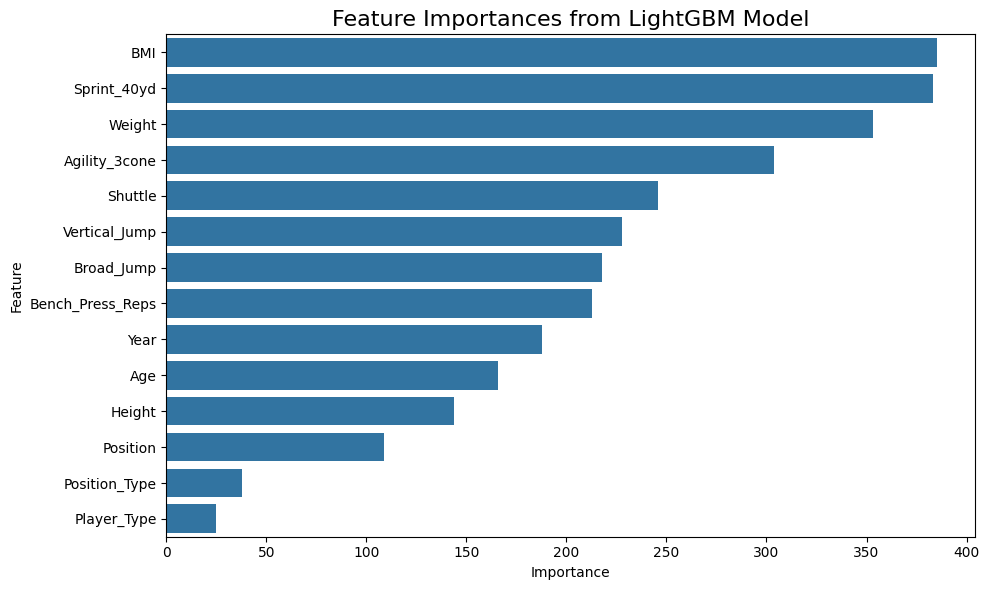

In [170]:
# Create a DataFrame of features and their importances
# This code assumes 'model' is a tree-based model like RandomForestClassifier or XGBoost, which has 'feature_importances_'
# If you want to use the feature importances from the RandomForestClassifier (the initial 'model'), you would need to ensure that 'model' variable still holds that instance.
# Alternatively, if you want feature importances from a different model (e.g., CatBoost or XGBoost), you would need to use that model's specific variable.

# Let's assume you want the feature importances from the *initial* RandomForestClassifier model.
# If that model's variable was 'model_rf' for example, you would use model_rf.feature_importances_.
# Since the latest 'model' variable is a Logistic Regression, which does not have this attribute,
# we need to revert 'model' to a tree-based model or use another tree-based model instance.

# For demonstration, let's assume 'model' was intended to be the RandomForestClassifier from fVrrEQmy-gXp.
# To fix this, you should re-run the Random Forest cell (fVrrEQmy-gXp) or rename the LogisticRegression model to something else (e.g., 'model_lr').
# For now, I will use the 'model_lgbm' as an example of a tree-based model that does have feature importances.
# Please adjust 'model_lgbm' to the actual tree-based model you wish to get importances from.

# NOTE: X is defined for the RandomForest, LightGBM, CatBoost and XGBoost models.
# If you want the feature importances for a specific model (e.g., the optimized CatBoost),
# you would use X_cat.columns and best_cb_model.feature_importances_ or model_xgb.feature_importances_ for XGBoost.

# Let's assume you want the importances for the LightGBM model ('model_lgbm') that was run before.
# We will use X_lgbm as features, and model_lgbm (which is an LGBMClassifier) to get importances.

feature_importances = pd.DataFrame({
    'Feature': X_lgbm.columns,
    'Importance': model_lgbm.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Importance', y='Feature')
plt.title('Feature Importances from LightGBM Model', fontsize=16)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The newly created feature, **BMI**, showed relatively high feature importance.

### [Next Steps]

We added only **BMI**. Many more features can be designed from this dataset:

- Build domain-driven features: ratios such as `Weight / Sprint_40yd`, or **Position**-specific summaries.
- Create interaction features between physical tests (e.g. `Vertical_Jump × Broad_Jump`).
- Use the feature-importance plot above to decide which features to keep, drop, or transform.
- Try binning numerical variables (e.g. **Age** into ranges) and treating them as categorical.

## 7.Create the Submission File

Finally, let's make a prediction for the test data, and prepare a CSV file to submit.

### Additional Feature Engineering

I will create some additional features based on combinations of existing numerical features, polynomial features, and a missing indicator for 'Age'.

In [172]:
# Create interaction features between key physical tests
for df in [train, test]:
    df['Vertical_x_Broad'] = df['Vertical_Jump'] * df['Broad_Jump']
    df['Sprint_x_Weight'] = df['Sprint_40yd'] * df['Weight']
    df['Agility_x_Shuttle'] = df['Agility_3cone'] * df['Shuttle']

In [173]:
# Create polynomial features for 'Age'
for df in [train, test]:
    df['Age_sq'] = df['Age'] ** 2
    df['Age_cub'] = df['Age'] ** 3

In [174]:
# Add a missing indicator for 'Age' (as it had a significant number of missing values originally)
# This is based on the state *before* imputation, but since we've already imputed, we'll create a new column
# that assumes an 'Age_Original_Missing' if Age is equal to the mean_value from the original imputation.
# A more robust approach would be to store this indicator *before* imputation.
# For now, I'll assume that any imputed 'Age' value (if it matches the mean) was originally missing.

# NOTE: This approach is a simplification. Ideally, the `Age_Missing` column should be created *before* imputation.
# Since imputation has already occurred, we'll use a proxy based on the imputed mean value.
# First, re-read the original data to get the true missing values for 'Age'
original_train = pd.read_csv(PATH / "train.csv")
original_test = pd.read_csv(PATH / "test.csv")

for df_orig, df_proc in zip([original_train, original_test], [train, test]):
    df_proc['Age_Missing'] = df_orig['Age'].isnull().astype(int)

Let's re-examine the `train` and `test` dataframes after adding these new features.

In [175]:
print('Train data after feature engineering:')
display(train.head())
print('\nTest data after feature engineering:')
display(test.head())

Train data after feature engineering:


,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,...,Position_Type,Position,Drafted,BMI,Vertical_x_Broad,Sprint_x_Weight,Agility_x_Shuttle,Age_sq,Age_cub,Age_Missing
0,2011,21.0,1.9050,140.160042,5.39,59.69,29.000000,251.46,7.910000,4.940000,...,5,4,1.0,38.621956,15009.6474,755.462628,39.07540,441.0,9261.0,0
1,2011,24.0,1.8288,87.089735,4.31,101.60,16.000000,332.74,7.230447,4.399422,...,0,13,1.0,26.039614,33806.3840,375.356758,31.80979,576.0,13824.0,0
2,2018,21.0,1.8542,92.986436,4.51,91.44,10.000000,309.88,6.950000,4.370000,...,0,13,1.0,27.046212,28335.4272,419.368826,30.37150,441.0,9261.0,0
3,2010,21.0,1.9304,148.778297,5.09,76.20,39.000000,254.00,8.120000,4.710000,...,2,16,1.0,39.925004,19354.8000,757.281534,38.24520,441.0,9261.0,0
4,2016,21.0,1.8796,92.079251,4.64,78.74,20.236408,281.94,7.130000,4.200000,...,0,13,1.0,26.063390,22199.9556,427.247725,29.94600,441.0,9261.0,0



Test data after feature engineering:


,Year,Age,Height,Weight,Sprint_40yd,Vertical_Jump,Bench_Press_Reps,Broad_Jump,Agility_3cone,Shuttle,Player_Type,Position_Type,Position,BMI,Vertical_x_Broad,Sprint_x_Weight,Agility_x_Shuttle,Age_sq,Age_cub,Age_Missing
0,2017,22.0,1.9558,136.077711,5.27,76.20,21.0,289.56,8.390000,5.09,1,5,4,35.574443,22064.4720,717.129537,42.705100,484.0,10648.0,0
1,2013,22.0,1.7780,83.460996,4.51,102.87,14.0,335.28,6.820000,3.84,0,1,1,26.400980,34490.2536,376.409092,26.188800,484.0,10648.0,0
2,2018,21.0,1.8542,103.419060,4.52,101.60,14.0,327.66,7.230447,4.34,1,0,9,30.080665,33290.2560,467.454153,31.380141,441.0,9261.0,0
3,2009,21.0,1.8034,98.429544,4.50,90.17,25.0,292.10,6.840000,4.27,1,0,9,30.265046,26338.6570,442.932949,29.206800,441.0,9261.0,0
4,2018,23.0,1.8288,83.914588,4.36,80.01,13.0,302.26,6.930000,4.40,0,1,1,25.090253,24183.8226,365.867606,30.492000,529.0,12167.0,0


### 7.1 Predicting on the test data
We found in Sections 5 and 6 that the best model was Random Forest model with BMI column added. Therefore, we will use this model to make the final prediction.

If you made any changes and found a better model, you will need to change the code below accordingly.

In [179]:
# Store predictions
test_pred_proba_list = []

# Train and evaluate using Stratified K-fold cross-validation
for fold, (train_idx, valid_idx) in enumerate(skf_cat.split(X_cat, y_cat)):
    X_train, X_valid = X_cat.iloc[train_idx], X_cat.iloc[valid_idx]
    y_train, y_valid = y_cat.iloc[train_idx], y_cat.iloc[valid_idx]

    # Train the best CatBoost model on this fold
    best_cb_model.fit(X_train, y_train)

    # Save predictions for the test set
    test_pred_proba = best_cb_model.predict_proba(test)[:, 1]
    test_pred_proba_list.append(test_pred_proba)

# Average test predictions across folds
test_pred_proba_mean = np.mean(test_pred_proba_list, axis=0)

### 7.2 Saving the prediction as CSV file [DO NOT CHANGE]
**WARNING**: DO **NOT** CHANGE THE CODES BELOW!!!

In [180]:
# Running this cell will generate the submission CSV file
submission = pd.read_csv(PATH / 'sample_submission.csv') # Update PATH in needed
submission["Drafted"] = test_pred_proba_mean
submission.to_csv(PATH / 'submission.csv', index=False)

At this point, you have successfully created a prediction CSV file that is ready for submission. Try submitting **submission.csv**.

## 8.Next Steps

In this notebook, we built a baseline model end to end—from preprocessing and feature engineering to model training and evaluation.

From here, you can use this baseline as a foundation and aim for higher accuracy by designing more advanced features and improving the modeling approach. For example, you might explore the following:

- Try different encoding methods for categorical features
- Try alternative missing-value imputation strategies
- Experiment with other models
- Tune model hyperparameters
- Develop additional feature engineering ideas

Let’s work toward a higher score!